# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import tensorflow
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
import joblib


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
BASE_DIR = os.path.join("..", "..", "Membangun_model", "california_housing_data")

RAW_DATA_PATH = os.path.join(BASE_DIR, "california_housing.csv")
OUTPUT_DIR = os.path.join(BASE_DIR, "namadataset_preprocessing")

SCALER_PATH = os.path.join(OUTPUT_DIR, "scaler.joblib")
TRAIN_PATH = os.path.join(OUTPUT_DIR, "train.csv")
TEST_PATH = os.path.join(OUTPUT_DIR, "test.csv")

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
print("Memuat data mentah...")

# Jika file belum ada → generate dataset simulasi
if not os.path.exists(RAW_DATA_PATH):
    print("Data mentah tidak ditemukan, membuat data simulasi California housing...")

    housing = fetch_california_housing()
    raw_data = pd.DataFrame(housing.data, columns=housing.feature_names)
    raw_data["MedHouseVal"] = housing.target

    raw_data.to_csv(RAW_DATA_PATH, index=False)
    print(f"Data mentah simulasi dibuat di {RAW_DATA_PATH}")
else:
    raw_data = pd.read_csv(RAW_DATA_PATH)

raw_data.head()


Memuat data mentah...


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
print("Shape of the dataset:", raw_data.shape)

Shape of the dataset: (20640, 9)


In [5]:
print("\nData types of each column:")
print(raw_data.dtypes)


Data types of each column:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
target        float64
dtype: object


In [6]:
print("\nMissing values in each column:")
print(raw_data.isnull().sum())
print("Data duplikat")
print(raw_data.duplicated().sum())


Missing values in each column:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64
Data duplikat
0


In [7]:
print("\nDescriptive statistics:")
display(raw_data.describe())


Descriptive statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [8]:
print("\nDistribution of target variable (target):")
display(raw_data['target'].value_counts())


Distribution of target variable (target):


target
5.00001    965
1.37500    122
1.62500    117
1.12500    103
1.87500     93
          ... 
3.59200      1
0.54900      1
3.77600      1
0.81200      1
0.47000      1
Name: count, Length: 3842, dtype: int64


Visualizing distributions of numerical features:


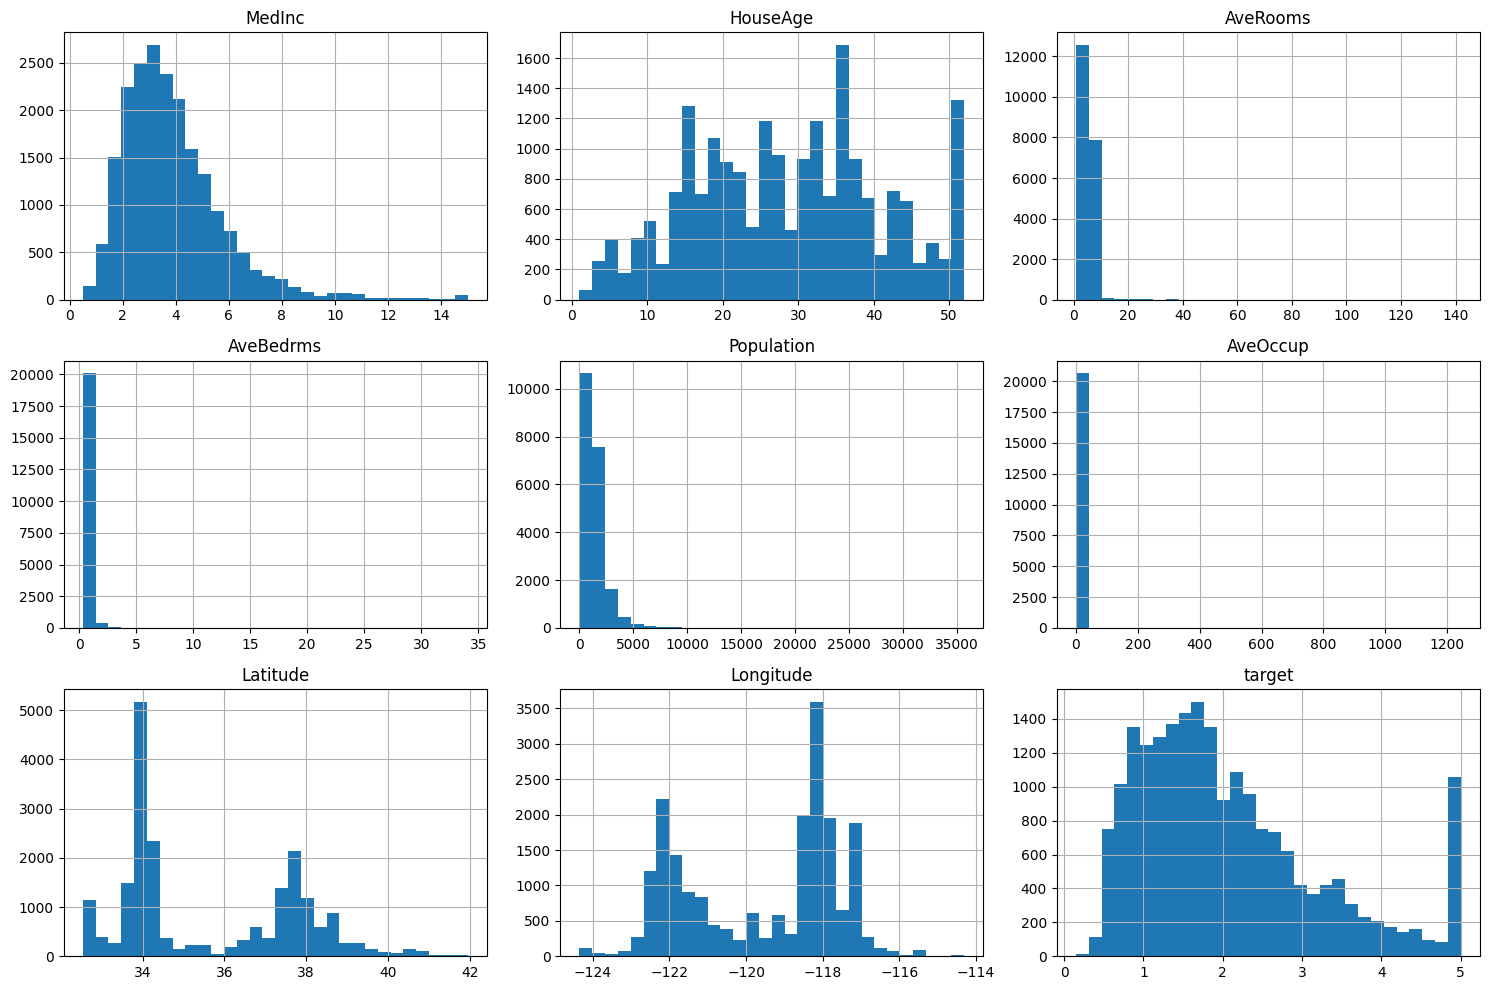

In [9]:
print("\nVisualizing distributions of numerical features:")
raw_data.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()


Visualizing correlations between features:


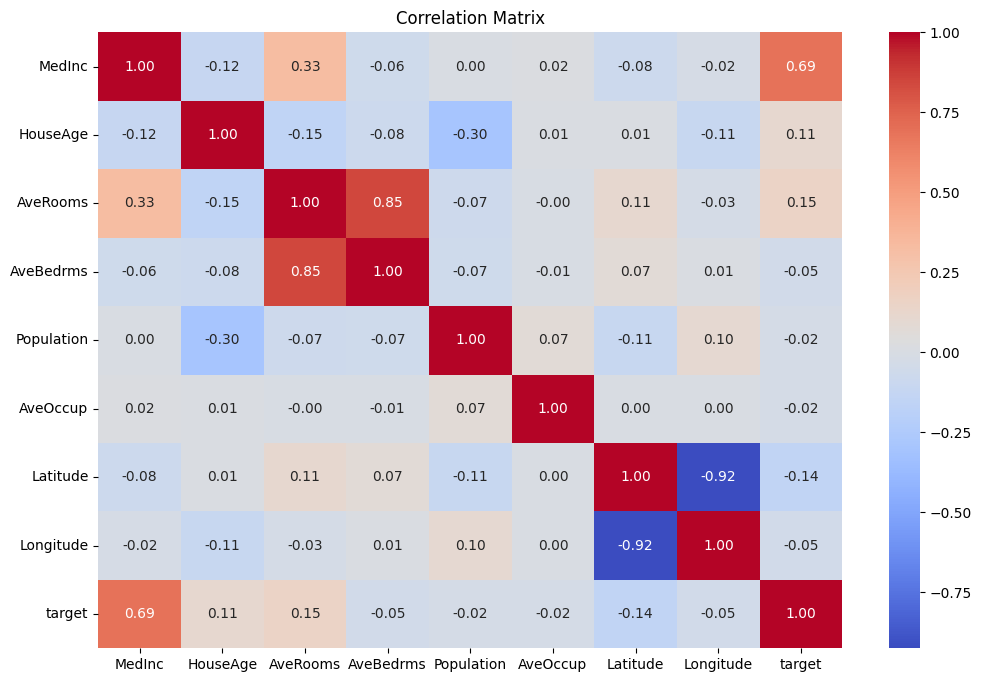

In [10]:
print("\nVisualizing correlations between features:")
plt.figure(figsize=(12, 8))
sns.heatmap(raw_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


Box plots to detect outliers:


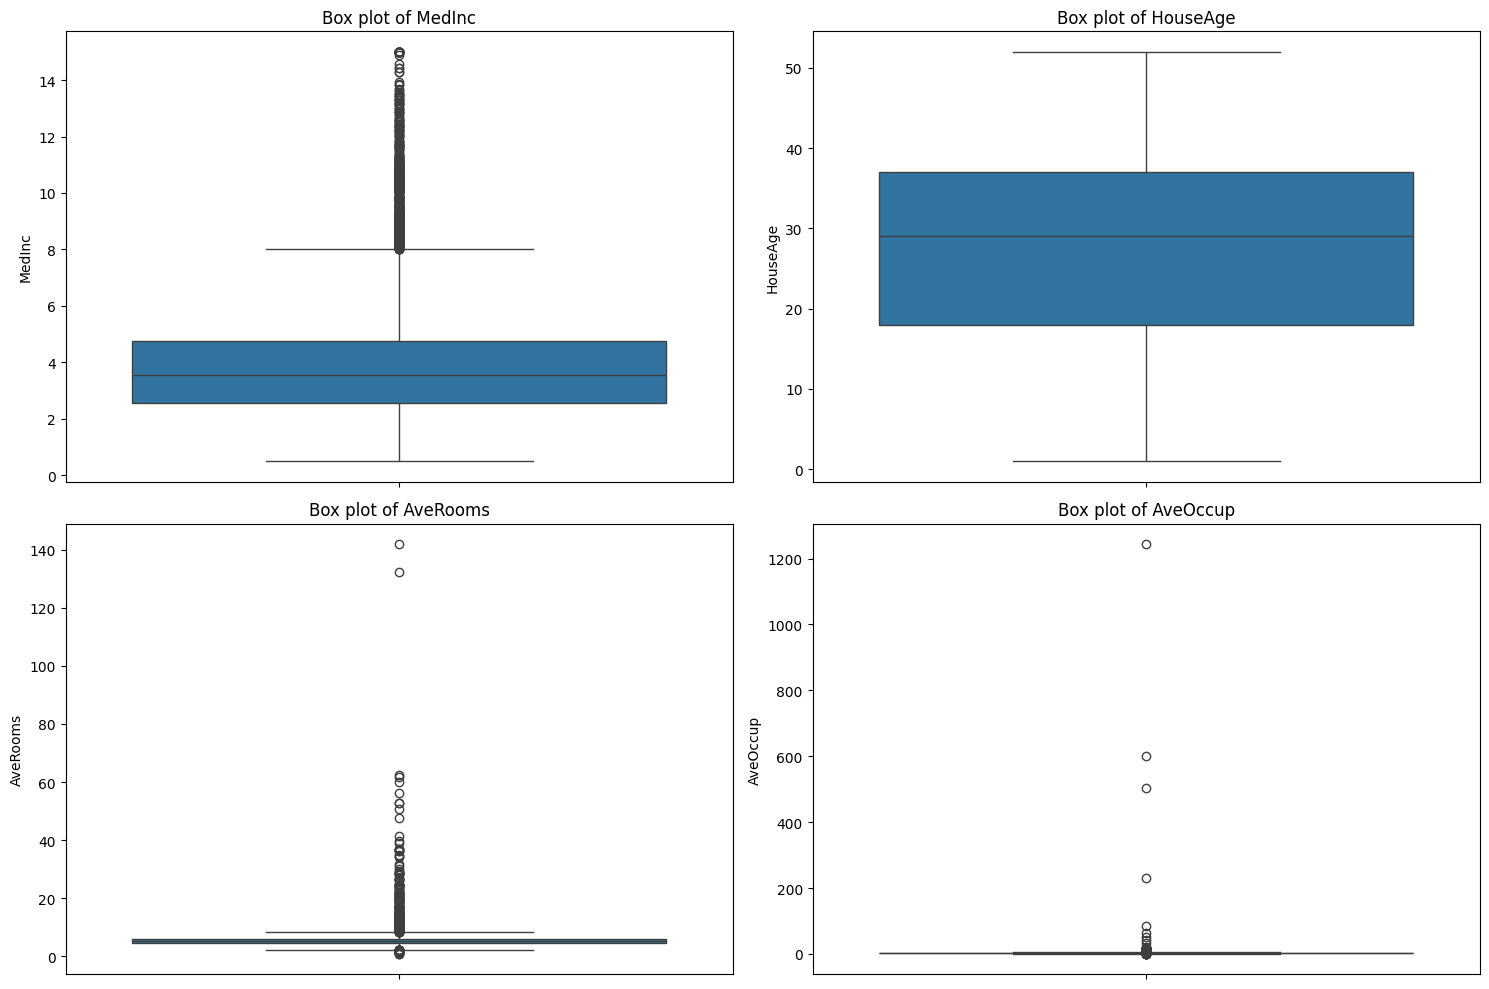

In [11]:
print("\nBox plots to detect outliers:")
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
sns.boxplot(y=raw_data['MedInc'])
plt.title('Box plot of MedInc')

plt.subplot(2, 2, 2)
sns.boxplot(y=raw_data['HouseAge'])
plt.title('Box plot of HouseAge')

plt.subplot(2, 2, 3)
sns.boxplot(y=raw_data['AveRooms'])
plt.title('Box plot of AveRooms')

plt.subplot(2, 2, 4)
sns.boxplot(y=raw_data['AveOccup'])
plt.title('Box plot of AveOccup')

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

Melakukan Standarisasi Pada fitur

In [12]:
from sklearn.preprocessing import MinMaxScaler

# Pilih fitur numerik yang akan distandarisasi
# Kita akan mengecualikan kolom target 'MedHouseVal'
numerical_features = raw_data.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_features.remove('target')

# Inisialisasi MinMaxScaler
scaler = MinMaxScaler()

# Lakukan min-max scaling pada fitur numerik
raw_data[numerical_features] = scaler.fit_transform(raw_data[numerical_features])

print("DataFrame setelah min-max scaling fitur:")
display(raw_data.head())

DataFrame setelah min-max scaling fitur:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,0.539668,0.784314,0.043512,0.020469,0.008941,0.001499,0.567481,0.211155,4.526
1,0.538027,0.392157,0.038224,0.018929,0.067210,0.001141,0.565356,0.212151,3.585
2,0.466028,1.000000,0.052756,0.021940,0.013818,0.001698,0.564293,0.210159,3.521
3,0.354699,1.000000,0.035241,0.021929,0.015555,0.001493,0.564293,0.209163,3.413
4,0.230776,1.000000,0.038534,0.022166,0.015752,0.001198,0.564293,0.209163,3.422



Visualizing distributions of numerical features:


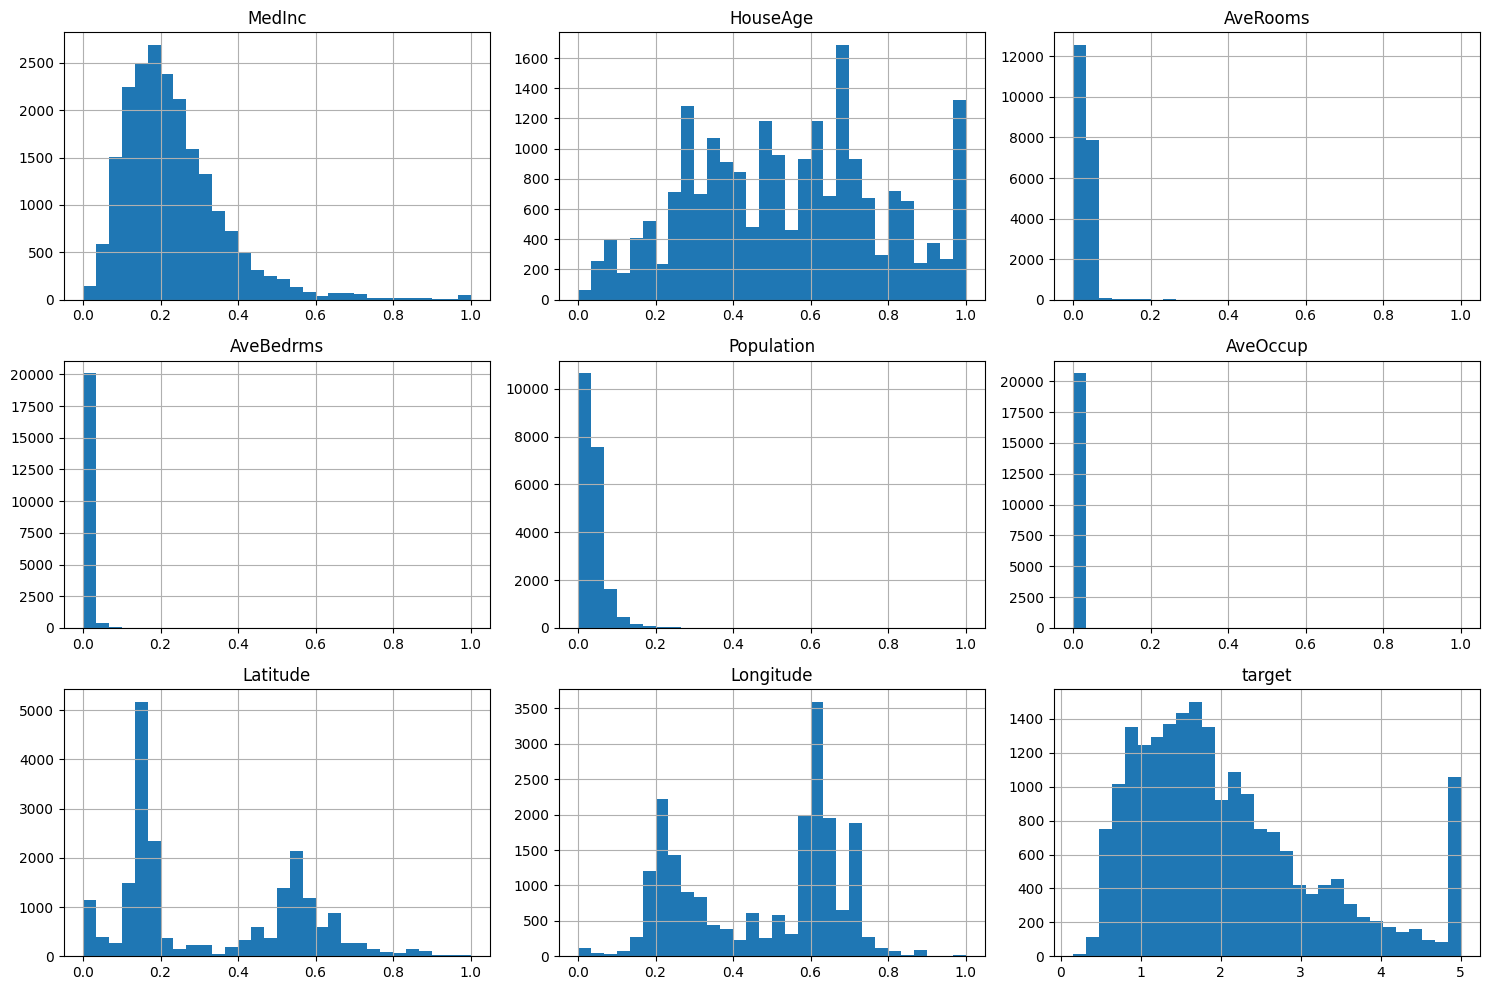

In [13]:
print("\nVisualizing distributions of numerical features:")
raw_data.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

Menangani Outlayer

In [14]:
from scipy import stats
import numpy as np

# Identifikasi fitur numerik untuk penanganan outlier (kecuali kolom target)
numerical_features_for_outliers = raw_data.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'target' in numerical_features_for_outliers:
    numerical_features_for_outliers.remove('target')

# Hitung Z-score untuk setiap nilai dalam fitur numerik
z_scores = np.abs(stats.zscore(raw_data[numerical_features_for_outliers]))

# Tentukan threshold Z-score (umumnya 3)
threshold = 3

# Filter DataFrame untuk menghapus outlier berdasarkan Z-score
raw_data_cleaned_zscore = raw_data[(z_scores < threshold).all(axis=1)]

print("Shape of DataFrame before outlier handling (Z-score):", raw_data.shape)
print("Shape of DataFrame after outlier handling (Z-score):", raw_data_cleaned_zscore.shape)

# Tampilkan beberapa baris pertama dari DataFrame yang sudah dibersihkan
display(raw_data_cleaned_zscore.head())

Shape of DataFrame before outlier handling (Z-score): (20640, 9)
Shape of DataFrame after outlier handling (Z-score): (19794, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,0.539668,0.784314,0.043512,0.020469,0.008941,0.001499,0.567481,0.211155,4.526
1,0.538027,0.392157,0.038224,0.018929,0.067210,0.001141,0.565356,0.212151,3.585
2,0.466028,1.000000,0.052756,0.021940,0.013818,0.001698,0.564293,0.210159,3.521
3,0.354699,1.000000,0.035241,0.021929,0.015555,0.001493,0.564293,0.209163,3.413
4,0.230776,1.000000,0.038534,0.022166,0.015752,0.001198,0.564293,0.209163,3.422



Box plots to detect outliers:


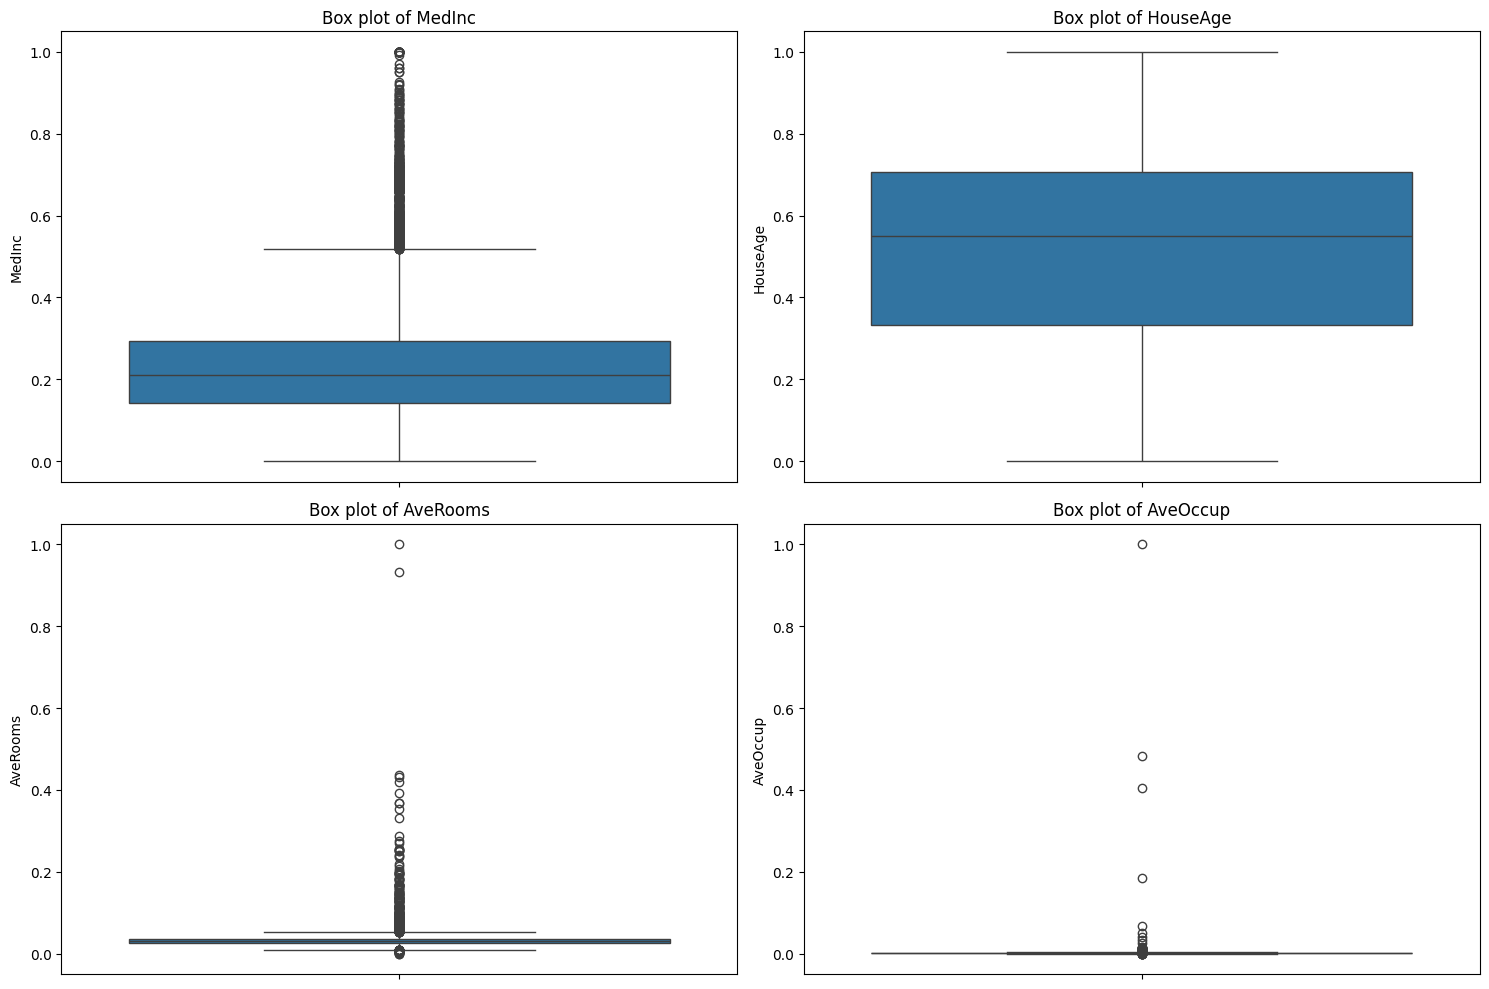

In [15]:
print("\nBox plots to detect outliers:")
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
sns.boxplot(y=raw_data['MedInc'])
plt.title('Box plot of MedInc')

plt.subplot(2, 2, 2)
sns.boxplot(y=raw_data['HouseAge'])
plt.title('Box plot of HouseAge')

plt.subplot(2, 2, 3)
sns.boxplot(y=raw_data['AveRooms'])
plt.title('Box plot of AveRooms')

plt.subplot(2, 2, 4)
sns.boxplot(y=raw_data['AveOccup'])
plt.title('Box plot of AveOccup')

plt.tight_layout()
plt.show()

In [16]:
raw_data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,0.539668,0.784314,0.043512,0.020469,0.008941,0.001499,0.567481,0.211155,4.526
1,0.538027,0.392157,0.038224,0.018929,0.067210,0.001141,0.565356,0.212151,3.585
2,0.466028,1.000000,0.052756,0.021940,0.013818,0.001698,0.564293,0.210159,3.521
3,0.354699,1.000000,0.035241,0.021929,0.015555,0.001493,0.564293,0.209163,3.413
4,0.230776,1.000000,0.038534,0.022166,0.015752,0.001198,0.564293,0.209163,3.422
...,...,...,...,...,...,...,...,...,...
20635,0.073130,0.470588,0.029769,0.023715,0.023599,0.001503,0.737513,0.324701,0.781
20636,0.141853,0.333333,0.037344,0.029124,0.009894,0.001956,0.738576,0.312749,0.771
20637,0.082764,0.313725,0.030904,0.023323,0.028140,0.001314,0.732200,0.311753,0.923
20638,0.094295,0.333333,0.031783,0.024859,0.020684,0.001152,0.732200,0.301793,0.847


In [17]:
# Validasi dataset
if "target" not in raw_data.columns:
    raise ValueError("Kolom 'target' tidak ditemukan di dataset!")

print("Dataset valid. Kolom target ditemukan.")
raw_data.head()


Dataset valid. Kolom target ditemukan.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,0.539668,0.784314,0.043512,0.020469,0.008941,0.001499,0.567481,0.211155,4.526
1,0.538027,0.392157,0.038224,0.018929,0.067210,0.001141,0.565356,0.212151,3.585
2,0.466028,1.000000,0.052756,0.021940,0.013818,0.001698,0.564293,0.210159,3.521
3,0.354699,1.000000,0.035241,0.021929,0.015555,0.001493,0.564293,0.209163,3.413
4,0.230776,1.000000,0.038534,0.022166,0.015752,0.001198,0.564293,0.209163,3.422


In [18]:
print("Memulai preprocessing...")

X = raw_data.drop("target", axis=1)
y = raw_data["target"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_raw.head()


Memulai preprocessing...


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,0.190322,0.627451,0.029572,0.019953,0.064380,0.002414,0.018066,0.729084
8267,0.228452,0.941176,0.025715,0.020978,0.036744,0.000842,0.130712,0.616534
17445,0.252162,0.058824,0.034025,0.019322,0.025561,0.001634,0.225292,0.385458
14265,0.099488,0.686275,0.022378,0.020765,0.039659,0.002657,0.015940,0.721116
2271,0.210638,0.823529,0.038439,0.023741,0.024412,0.001294,0.450584,0.453187


In [19]:
scaler = StandardScaler()
scaler.fit(X_train_raw)

X_train_scaled = scaler.transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)


In [20]:
train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
train_df["target"] = y_train.values

test_df = pd.DataFrame(X_test_scaled, columns=X.columns)
test_df["target"] = y_test.values

train_df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587,1.030
1,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162,3.821
2,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603,1.726
3,-1.017864,0.586545,-0.600015,-0.145156,-0.007434,0.077507,-1.382172,1.232698,0.934
4,-0.171488,1.142008,0.349007,0.086624,-0.485877,-0.068832,0.532084,-0.108551,0.965


In [21]:
train_df.to_csv(TRAIN_PATH, index=False)
test_df.to_csv(TEST_PATH, index=False)
joblib.dump(scaler, SCALER_PATH)

print("Preprocessing selesai.")
print(f"Data train disimpan di: {TRAIN_PATH}")
print(f"Data test disimpan di: {TEST_PATH}")
print(f"Scaler disimpan di: {SCALER_PATH}")


Preprocessing selesai.
Data train disimpan di: ..\..\Membangun_model\california_housing_data\namadataset_preprocessing\train.csv
Data test disimpan di: ..\..\Membangun_model\california_housing_data\namadataset_preprocessing\test.csv
Scaler disimpan di: ..\..\Membangun_model\california_housing_data\namadataset_preprocessing\scaler.joblib
